In [1]:
%matplotlib widget

In [2]:
import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
import pygimli as pg
from sklearn.metrics import root_mean_squared_error
from scipy.constants import mu_0
import math
import time
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import sys
sys.path.insert(1, '../src')

from showStitched import showStitchedModels

from FDEM1D import FDEM1DModelling, LCModelling

from matplotlib.colors import LogNorm
plt.style.use('bmh')

L = LogNorm(vmin=0.001, vmax=1)
popts = {'norm': L}

In [3]:
model_true = np.load('model_Sinu.npy')[:-3]

model_true[:,1] = model_true[:,1]*1000
model_true[:,2] = model_true[:,2]*1000

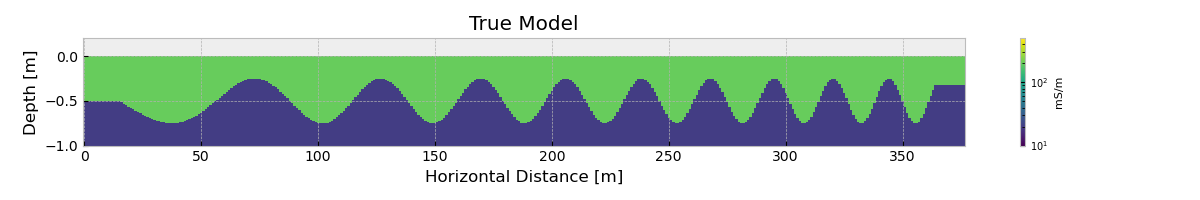

In [4]:
fig, ax = plt.subplots(figsize=(12,2))

inputs= {'label' : 'mS/m'}

showStitchedModels(model_true, zMax=2, ax=ax, cMin=10, cMax=500, **inputs)
ax.set_ylim([-1, 0.2])
ax.set_title('True Model')
ax.set_xlabel('Horizontal Distance [m]')
ax.set_ylabel('Depth [m]')
plt.tight_layout()


In [18]:
data_true = np.load('data_3D_Sinusoidal_sorted.npy')
midp_x = np.load('midpx_data_Sinu.npy')

norm = np.array([4, 2, 1, 4, 2, 1, 4, 2, 1, 8, 4, 1, 8, 4, 1, 8, 4, 1])
data_true_norm = data_true[:] * norm

In [19]:
print(len(model_true))
print(len(data_true))

377
377


In [20]:
i1 = 0
i2 = 377

In [21]:
# Define a start model
model_ini = np.ones_like(model_true[i1:i2])
model_ini[:,0] = model_ini[:,0]*1   # initial thickness h_1
model_ini[:,1] = model_ini[:,1]*0.05 # initial sigma_1
model_ini[:,2] = model_ini[:,2]*0.05 # initial sigma_2

data_true_norm =  data_true_norm[i1:i2]

In [32]:
# number of layers
nLayers = np.shape(model_true)[1] -1

# number of measurement positions 
npos = len(data_true_norm)

LCI = LCModelling(FDEM1DModelling)

hw = 1
sw = 1

LCI.initJacobian(dataVals=data_true_norm, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data_true_norm, nLay=nLayers)
LCI.normalization(data_true_norm, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data_true_norm, cWeight_1=hw, cWeight_2=sw, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,2)
transSig = pg.trans.TransLogLU(1/1000, 300/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data_true_norm.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3 

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
model_inv = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1)

model_inv = np.array(model_inv).reshape(np.shape(model_true[i1:i2]))
data_inv = np.array(inv.response)
data_inv = data_inv.reshape(np.shape(data_true_norm))

Inversion is normalized
Jacobian size: 6768 1128 6786


20/01/25 - 13:51:36 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper


cWeights are equal
Constraint cWeight length: 1128
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7fed952c3bf0>


20/01/25 - 13:51:40 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


In [33]:
model_inv = np.array(model_inv)

In [34]:
model_h_rmse = root_mean_squared_error(model_true[i1:i2,0].ravel(), model_inv[:,0].ravel())
model_s_rmse = root_mean_squared_error(model_true[i1:i2,1:].ravel(), (model_inv[:,1:]*1000).ravel())
data_rmse = root_mean_squared_error(data_true_norm.ravel(), data_inv.ravel())*1000

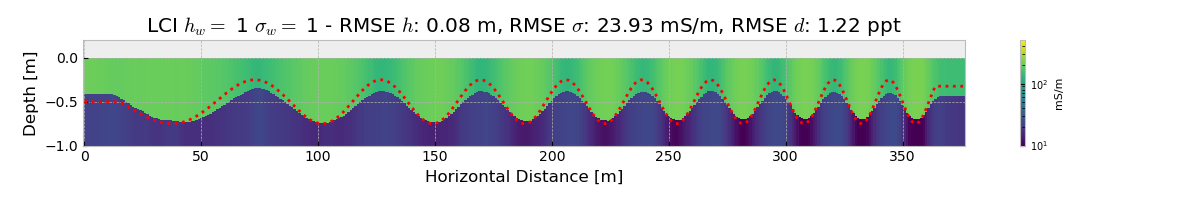

In [35]:
fig, ax = plt.subplots(figsize=(12,2))

model_inv_ = model_inv.copy()
model_inv_[:,1] = model_inv[:,1]*1000
model_inv_[:,2] = model_inv[:,2]*1000

showStitchedModels(model_inv_,  zMax=4, cMin=10, cMax=500, ax=ax, **inputs)
ax.set_title(f'LCI $h_w = $ {hw} $\sigma_w = $ {sw} - RMSE $h$: {model_h_rmse:.2f} m, RMSE $\sigma$: {model_s_rmse:.2f} mS/m, RMSE $d$: {data_rmse:.2f} ppt')
#ax.set_title(f'PWI - RMSE $h$: {model_h_rmse:.2f} m, RMSE $\sigma$: {model_s_rmse:.2f} mS/m, RMSE $d$: {data_rmse:.2f} ppt')
ax.set_ylim([-1, 0.2])
ax.plot(-model_true[i1:i2,0], ':r')
ax.set_xlabel('Horizontal Distance [m]')
ax.set_ylabel('Depth [m]')
plt.tight_layout()